# Learning `EBP_sweep`: Eclipse Timing and Apsidal Precession



## 0. Introduction

**Binary Stars** are stars that orbit one another. 


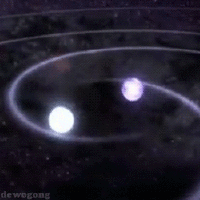

In [19]:
# load binary.gif into notebook
from IPython.display import Image
Image(filename='binary.gif')


Eclipse Binaries are those that regularly pass in front of each other from out point of view. As they 'eclipse' one another, we see periodic dips in the lightcurve.

![alt text](https://cosmosatyourdoorstep.com/wp-content/uploads/2018/05/ceafb739be6322649c8875ba91817af4.jpg)

**Target star: `TIC 343127696`**

This notebook is a hands-on tutorial for the [`EBP_sweep`](../README.md) package. It measures
eclipse timing variations (ETVs) in eclipsing binaries from TESS photometry, which is the raw
material for detecting **apsidal precession** — the slow rotation of an eccentric binary's orbit.

### Learning objectives

By the end of this notebook you will be able to:

1. Explain, in your own words, what an O&ndash;C diagram measures and why the *difference* between
	 the primary and secondary eclipse periods is diagnostic of apsidal precession.
2. Use `EBP_sweep` to download and clean a TESS light curve, find the orbital period, and separate
	 primary and secondary eclipses.
3. Compare five independent eclipse-timing methods and explain (qualitatively) how each one works.
4. Build an O&ndash;C diagram, and read off which method gives the least-scattered eclipse times.
5. Run the whole pipeline in one line using `EclipsingBinaryTarget`, once you understand what it's
	 doing under the hood.

### Prerequisites

- `EBP_sweep` installed in your Python environment (`pip install -e ".[dev]"` from the package
	root — see the top-level `README.md`).
- An internet connection: this notebook downloads real TESS data for `TIC 343127696` the first
	time each cell runs (`lightkurve` caches it locally afterwards, under `~/.lightkurve/cache`).
- Some cells take a minute or two — BLS/TLS period searches and per-eclipse model fits are not
	instant. This is normal; read the explanation while you wait.

> **Where does the output go?** Every stage below writes diagnostic plots to `./Figures/` and
> data/log files to `./Data/`, relative to wherever you launch this notebook from. Run it from an
> empty working directory if you don't want it mixed in with other files.


## 1. Background: why measure eclipse times?



An **eclipsing binary** is a pair of stars whose orbit happens to be edge-on to us, so each star
periodically blocks the other's light. Two distinct eclipses occur per orbit:

- the **primary eclipse**, when the hotter/brighter star is blocked (deeper dip), and
- the **secondary eclipse**, when the fainter star is blocked (shallower dip).

If the orbit is circular, the secondary eclipse falls exactly halfway between consecutive primary
eclipses. If the orbit is **eccentric**, it doesn't — the phase separation between the two
eclipses encodes $e\cos\omega$, where $e$ is the eccentricity and $\omega$ is the argument of
periastron.

### Apsidal precession

Tidal bulges, rotational distortion, a third body, or general relativity can all make $\omega$
slowly rotate over time — this is **apsidal precession**. Because the eclipse phase separation
depends on $\omega$, precession makes the *primary* and *secondary* eclipse periods (the time
between consecutive eclipses of the same type) drift apart from each other, ever so slightly,
year after year.

This means the core measurement is: **get many precise primary and secondary eclipse times,
spread over as long a baseline as possible, and compare $P_\mathrm{primary}$ to
$P_\mathrm{secondary}$.**

### The O&ndash;C diagram

The standard tool for this is the Observed–Calculated **O&ndash;C diagram** : for each observed eclipse time
$T_\mathrm{obs}$, compute a *calculated* time from a linear ephemeris,
$T_\mathrm{calc} = T_0 + E \times P$ (where $E$ is the integer epoch number), and plot
$T_\mathrm{obs} - T_\mathrm{calc}$ against time (or Epoch). A flat, scattered O&ndash;C means the linear
ephemeris is a good fit (no period change over the baseline you have); a trend or curvature means
the *effective* period is drifting, which is what a slow difference between
$P_\mathrm{primary}$ and $P_\mathrm{secondary}$ produces.

`EBP_sweep` automates the whole path from "raw TESS light curve" to "O&ndash;C diagram and refined
primary/secondary periods" for one target at a time. Let's walk through it.


## 2. Setup



Import the package and check it's installed correctly. If this raises `ModuleNotFoundError`, go
back to the package root and run `pip install -e ".[dev]"` in the environment this notebook's
kernel is using.


In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")  # astroquery/lightkurve are chatty; safe to silence for this tutorial

import EBP_sweep
print(f"EBP_sweep version {EBP_sweep.__version__}, loaded from {EBP_sweep.__file__}")


EBP_sweep version 0.1.0, loaded from /Users/tunde/Library/CloudStorage/OneDrive-UNSW/Postdoc_science/Binary_work/apsidal_precession_code/EBP_sweep/src/EBP_sweep/__init__.py


`EBP_sweep` is organised as several small modules, each responsible for one pipeline stage. We'll
import them individually as we go so it's clear which module each function lives in — but note
that the whole thing is also available as one class, `EclipsingBinaryTarget`, which we'll use at
the end once you've seen what it does step by step.

| Module | Responsibility |
|---|---|
| `EBP_sweep.io` | Download and clean TESS light curves|
| `EBP_sweep.periods` | BLS/TLS period search; separate primary and secondary eclipses |
| `EBP_sweep.timing` | Four eclipse-timing methods (half-depth, fold, cross-correlation, ingress/egress) + O&ndash;C |
| `EBP_sweep.batman_fit` | A fifth eclipse-timing method: full transit-model fitting |
| `EBP_sweep.plotting` | Diagnostic and summary plots |
| `EBP_sweep.reporting` | One-page PDF data-validation summaries |
| `EBP_sweep.pipeline` | `EclipsingBinaryTarget`, `run_target`, `run_many` — the whole thing, wrapped up |


## 3. Warm-up: a couple of building blocks (no internet needed)

Before we download any data, let's get a feel for two small, self-contained functions the
pipeline relies on internally. Understanding these now will make the later steps easier to follow.

### 3.1 `robust_std` — a noise estimator that ignores outliers

Ordinary standard deviation is sensitive to outliers (like the eclipses themselves, which are
*not* noise). `EBP_sweep.utils.robust_std` instead uses the Median Absolute Deviation (MAD),
scaled to match the standard deviation for normally-distributed data. This function is used to estimate the scatter around each eclipse event.


In [4]:
import numpy as np
from EBP_sweep.utils import robust_std

rng = np.random.default_rng(0)
clean_noise = rng.normal(loc=0.0, scale=1.0, size=2000)
noise_with_outliers = np.concatenate([clean_noise, [50, -50, 80]])  # a few extreme outliers

print(f"Ordinary np.std,  clean data:      {np.std(clean_noise):.3f}")
print(f"Ordinary np.std,  with outliers:   {np.std(noise_with_outliers):.3f}   <- badly inflated")
print(f"robust_std,       with outliers:   {robust_std(noise_with_outliers):.3f}   <- still ~1.0")


Ordinary np.std,  clean data:      1.000
Ordinary np.std,  with outliers:   2.587   <- badly inflated
robust_std,       with outliers:   1.015   <- still ~1.0


## 4. Step 1 — Download and clean the light curve

`EBP_sweep.io.load_and_clean_lc` searches the MAST archive for QLP (Quick-Look Pipeline) light
curves of our target, downloads every available TESS sector, stitches them together, and removes
bad cadences and background-contaminated points.

The `quality_bitmask` argument controls how aggressively bad cadences are discarded:

| Value | Meaning |
|---|---|
| `'none'` | Keep everything |
| `'default'` | Discard cadences with severe quality issues |
| `'hard'` | More conservative — known to remove some good data too |
| `'hardest'` | Discard anything flagged at all — not usually recommended |

We'll use `'hard'` here.

This cell downloads several TESS sectors of data and will take a minute or so the first time you
run it.


In [6]:
from EBP_sweep.io import load_and_clean_lc

TIC_ID = "TIC 343127696"
QUALITY_BITMASK = "hard"

good_lc = load_and_clean_lc(TIC_ID, QUALITY_BITMASK)
print(f"\nCleaned light curve: {len(good_lc)} points across {len(np.unique(good_lc.sector))} sectors")


	Saved all sectors plot to Figures/AllSectors/TIC343127696_All_Sectors.jpg

Cleaned light curve: 50258 points across 7 sectors


<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

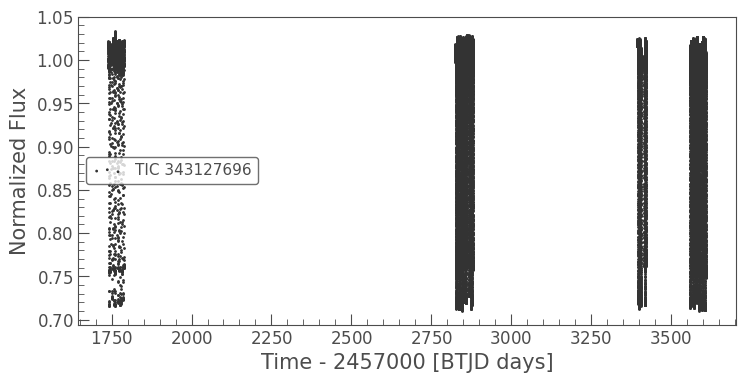

In [21]:
# you can plot the cleaned light curve with the scatter() method. Since the sectors can be be very far
# from each other, this plot may not be very useful
good_lc.scatter()

However, running `load_and_clean_lc()` also saved a clearer diagnostic plot to `./Figures/AllSectors/TIC343127696_All_Sectors.jpg` — open
it now and look for two things: (1) do the eclipses look periodic and consistent from sector to
sector, and (2) are there any obviously bad points (spikes, discontinuities) that survived
cleaning? Keep this in mind; if a later stage fails, this is usually the first plot to check.

## 5. Step 2 — Find the orbital period

`EBP_sweep.periods.find_orbital_period` combines two period-search algorithms:

1. **BLS (Box Least Squares)** searches for periodic, box-shaped dips — a good match to eclipse
	shapes — over a coarse period grid to get a first estimate.
2. **TLS (Transit Least Squares)** then refines that estimate with a more realistic (limb-darkened)
	eclipse shape template, searched over a narrow window around the BLS period.

Along the way, the function also checks for the classic BLS failure modes: finding exactly half
the true period (if the primary and secondary eclipses look similar enough to be confused for one
periodic signal) or exactly double it, and corrects for them automatically
(see `EBP_sweep.periods.correct_bls_period` if you want to read the logic).


In [7]:
from EBP_sweep.periods import find_orbital_period

P_TLS, results_TLS = find_orbital_period(TIC_ID, good_lc)
print(f"\nOrbital period found: {P_TLS:.6f} days")


Transit Least Squares TLS 1.33 (19 Aug 2024)
Creating model cache for 29 durations
Searching 50258 data points, 1184 periods from 4.625 to 4.719 days
Using all 8 CPU threads
Searching for best T0 for period 4.67232 days

Orbital period found: 4.672318 days


**Note** `results_TLS` is the full TLS result object (it has attributes
like `.T0`, `.duration`, `.depth`, `.transit_times`, ...). Print `results_TLS.T0` and
`results_TLS.duration` below 

In [8]:
# Your exploration here:
print("T0 (reference eclipse time):", results_TLS.T0)
print("Eclipse duration estimate:  ", results_TLS.duration)


T0 (reference eclipse time): 1742.6799076546056
Eclipse duration estimate:   0.028703322272561737


## 6. Step 3 — Flatten and phase-fold

Raw TESS flux has slow instrumental/stellar trends on top of the eclipses. `prepare_flat_lc`:

1. Flattens the light curve **sector by sector** (each TESS sector can have a different trend),
	masking out points near predicted eclipses first so the eclipses are not affected by the trend fit.
2. Phase-folds the flattened, stitched light curve on the period we just found, so all eclipses
	from all sectors line up on top of each other.


In [9]:
from EBP_sweep.periods import prepare_flat_lc

flat_lc, t0, phased, o_factor = prepare_flat_lc(TIC_ID, good_lc, P_TLS, results_TLS)
print(f"\nFlattened light curve: {len(flat_lc)} points; reference time t0 = {t0:.5f} BTJD")


	Saved all sectors plot to Figures/AllSectors/TIC343127696_All_Sectorsdetrended.jpg
	Saved phase-fold plot to Figures/AllSectors/TIC343127696_Allphased_TLS.jpg
	Combined raw, detrended, and phased data in multipage PDF: Figures/AllSectors/TIC343127696_All_Sectors_multipage.pdf

Flattened light curve: 50258 points; reference time t0 = 1743.61437 BTJD


<Axes: xlabel='Phase (Normalized)', ylabel='Normalized Flux'>

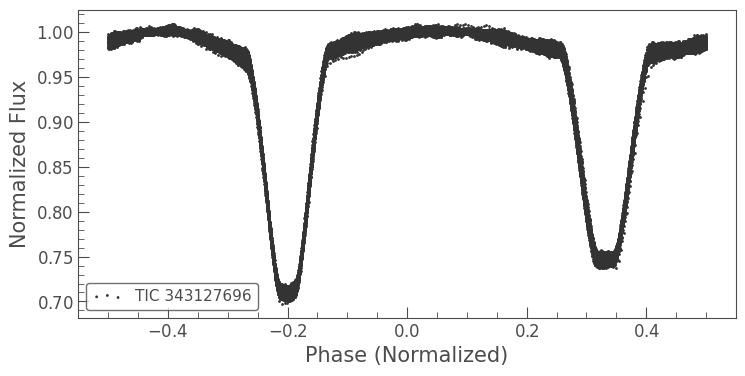

In [10]:
phased.scatter()

Open the [multipage pdf](./Figures/AllSectors/TIC343127696_All_Sectors_multipage.pdf). You should see **two** distinct
dips in the phase-folded light curve — the primary (deeper) and secondary (shallower) eclipse.
If you only see one dip, or more than two, that's a sign the period is wrong (see the BLS
half/double-period issue mentioned above) — but for this target it should look clean.


## 7. Step 4 — Separate the primary and secondary eclipses

So far we have one phase-folded light curve containing *both* eclipse types. `separate_eclipses`
locates each eclipse type using TLS again (once with the primary eclipses masked out, to isolate
the secondary; once with the secondary masked out, to isolate the primary), and returns a
dictionary with everything downstream steps need: both periods, both phase-folded light curves,
and the light curves with the *other* eclipse type removed.


In [ ]:
from EBP_sweep.periods import separate_eclipses

ecl = separate_eclipses(TIC_ID, flat_lc, phased, P_TLS, t0, o_factor)
print("Keys in the eclipse dictionary:")
for key in ecl:
	print("-->", key)

print(f"\nP_primary   = {ecl['P_primary']:.6f} d")
print(f"P_secondary = {ecl['P_secondary']:.6f} d")


Transit Least Squares TLS 1.33 (19 Aug 2024)
Creating model cache for 29 durations
Searching 26966 data points, 1185 periods from 4.626 to 4.719 days
Using all 8 CPU threads
Searching for best T0 for period 4.67224 days
Transit Least Squares TLS 1.33 (19 Aug 2024)
Creating model cache for 29 durations
Searching 29055 data points, 1185 periods from 4.626 to 4.719 days
Using all 8 CPU threads
Searching for best T0 for period 4.67232 days
Keys in the eclipse dictionary:
--> P_primary
--> P_secondary
--> t0
--> phased
--> phased_primary
--> phased_secondary
--> lc_nonsecondary
--> lc_nonprimary
--> results_primary
--> results_secondary
--> primary_xlims
--> secondary_xlims
--> phased_primary_on_secondary
--> phased_secondary_on_primary

P_primary   = 4.672318 d
P_secondary = 4.672239 d


Notice `P_primary` and `P_secondary` are already two independent period measurements at this
point — from two independent TLS searches on two different (eclipse-masked) light curves. They
should agree closely (they're the same orbital period!), but they won't be *identical* — the tiny
difference here is noise, not precession; we'll get a much more precise version of this comparison
after eclipse timing in Section 8.

Now let's visualize the separation with the package's four-panel diagnostic plot.


	Saved 4-panel plot to Figures/4panels/TIC343127696_4panel_new.png


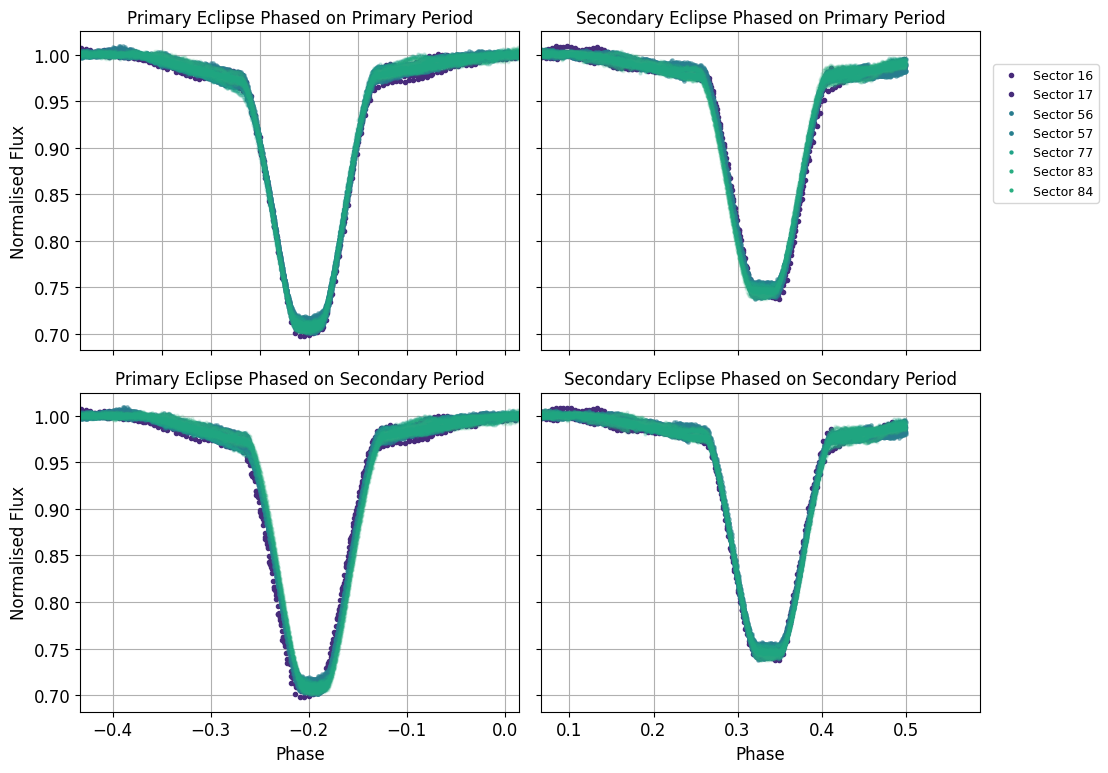

In [ ]:
from EBP_sweep.plotting import plot_subfigures

plot_subfigures(
	TIC_ID,
	ecl["phased_primary"], ecl["phased_secondary"],
	ecl["phased_secondary_on_primary"], ecl["phased_primary_on_secondary"],
	ecl["primary_xlims"], ecl["secondary_xlims"],
)


This saves (and, depending on your matplotlib backend, may also display) a 2x2 grid:

- **top-left**: primary eclipse, phased on the primary period
- **top-right**: secondary eclipse, phased on the *primary* period (the eclipses should look mismatched)
- **bottom-left**: primary eclipse, phased on the *secondary* period (should also look mismatched)
- **bottom-right**: secondary eclipse, phased on the secondary period


## 8. Step 5 — Measure individual eclipse times, five ways

This is the heart of the pipeline. For *every* eclipse of *both* types, `EBP_sweep` estimates the
precise mid-eclipse time using up to five independent methods, each with different strengths:

| Method | Idea | Typically... |
|---|---|---|
| `hd` (half-depth) | Find where flux crosses the halfway point between baseline and eclipse minimum, on ingress and egress; average the two times | Fast, simple, sensitive to noise near the crossing points |
| `fold` | Find the time that best makes the ingress and egress sides mirror-symmetric | Robust to a single noisy point, needs good phase coverage |
| `cc` (cross-correlation) | Fit a smooth spline to *all* eclipses of this type pooled together, then slide it against each individual eclipse to find the best-matching shift | Uses the average eclipse shape as a template — the pooled shape is less sensitive to individual point noise |
| `gress` (ingress/egress) | Like `cc`, but fits ingress and egress *separately* against their own template shapes | Useful if ingress/egress are asymmetric (e.g. star spots) |
| `batman` | Fit a full physical eclipse model (via the `batman` package) — first pool all eclipses to get one precise shape (depth, duration, impact parameter, limb darkening), then re-fit *only* the timing per eclipse holding the shape fixed | Most physically motivated method |

Run all five now. This is the slowest step in the pipeline — expect this cell to take
a few minutes.


In [ ]:
from EBP_sweep.timing import compute_eclipse_times

(obs_pri, obs_sec, err_pri, err_sec), methods = compute_eclipse_times(
	TIC_ID, ecl, epoch_width=0.2, methods=["hd", "fold", "cc", "gress", "batman"]
)

print("\nMethods computed (in order):", methods)
for i, method in enumerate(methods):
	print(f"  {method:6s}: {len(obs_pri[i])} primary eclipses, {len(obs_sec[i])} secondary eclipses timed")


Fitting primary eclipses with batman model...
	GLOBAL FIT: Fit succeeded.
	Fitting 33 individual eclipses
	Saved epoch fits to Figures/EpochTimes/TIC343127696_EpochFits_pri_batman_P4.6723.pdf
	P_bat (pri) = 4.6723054+/-0.0000007 days
Fitting secondary eclipses with batman model...
	GLOBAL FIT: Fit succeeded.
	Fitting 32 individual eclipses
	Saved epoch fits to Figures/EpochTimes/TIC343127696_EpochFits_sec_batman_P4.6722.pdf
	P_bat (sec) = 4.6722590+/-0.0000007 days
Getting pri eclipse times using half-depth and folding methods ...
	Saving 33 pri eclipse times for half-depth and folding methods to pdf ...
	Saved epoch fits to Figures/EpochTimes/TIC343127696_EpochFits_pri_half_depth_P4.6723.pdf
Getting pri eclipse times using Cross-Correlation and Ingress/Egress methods ...
	Obtained 33 pri eclipse times for Cross-Correlation and Ingress/Egress methods...
Getting sec eclipse times using half-depth and folding methods ...
	Saving 32 sec eclipse times for half-depth and folding methods to 

Each method didn't necessarily time *every* eclipse — an eclipse with poor phase coverage (e.g.
right at the edge of a TESS sector) might be skipped by one method but not another. That's fine;
the next step handles methods/eclipses of differing size.

Have a look at the per-eclipse fit diagnostics saved to `./Figures/EpochTimes/` — in particular
`TIC343127696_EpochFits_pri_batman_P*.pdf` shows every individual primary eclipse with its
best-fit `batman` model overlaid. Do the fits look reasonable? Are there any eclipses where the
model clearly doesn't match the data?


## 9. Step 6 — Build the O&ndash;C diagram and refine the periods

Now we bring everything together. `compute_oc_and_best_period`:

1. For each method, fits a linear ephemeris to that method's eclipse times and computes the
	weighted RMS scatter of the residuals (the O&ndash;C values) — this tells us how *precise*
	that method's eclipse times are, relative to their own error bars.
2. Picks the lowest-scatter method independently for the primary and secondary eclipses (it does
	not have to be the same method for both).
3. Uses the *slope* of each method's linear fit to nudge the coarse `P_primary` / `P_secondary`
	from Section 7 into much more precise, eclipse-timing-based period estimates.
4. Saves the O&ndash;C values to `./Data/OC_txtfiles/` for external analysis.


In [ ]:
from EBP_sweep.timing import compute_oc_and_best_period

oc = compute_oc_and_best_period(
	TIC_ID, obs_pri, obs_sec, err_pri, err_sec,
	ecl["P_primary"], ecl["P_secondary"], methods,
)

bi_pri, bi_sec = oc["best_index_primary"], oc["best_index_secondary"]
print(f"Best primary method:   {methods[bi_pri]}  (scatter = {oc['pri_stds'][bi_pri]:.3f} min)")
print(f"Best secondary method: {methods[bi_sec]}  (scatter = {oc['sec_stds'][bi_sec]:.3f} min)")
print()
print(f"Refined P_primary   = {oc['P_primary_new']:.8f} +/- {oc['pri_uncerts'][bi_pri]:.2e} d")
print(f"Refined P_secondary = {oc['P_secondary_new']:.8f} +/- {oc['sec_uncerts'][bi_sec]:.2e} d")
print()
period_diff = oc["P_primary_new"] - oc["P_secondary_new"]
print(f"P_primary - P_secondary = {period_diff * 24 * 3600:.3f} seconds")



Best primary method index: 4 (batman), Best secondary method index: 4 (batman)
Best primary method:   batman  (scatter = 2.033 min)
Best secondary method: batman  (scatter = 2.292 min)

Refined P_primary   = 4.67229564 +/- 8.61e-04 d
Refined P_secondary = 4.67226128 +/- 9.87e-04 d

P_primary - P_secondary = 2.969 seconds


### This last number is the punchline of the whole notebook.

With only two or three TESS sectors of data, `P_primary - P_secondary` is dominated by
measurement noise, not real apsidal precession (which needs a long time baseline — years to
decades — to build up a measurable signal via this method). But this is exactly the quantity that,
tracked over many years and many more sectors, is used to measure real apsidal precession rates:
if a system has a genuinely precessing orbit, $P_\mathrm{primary}$ and $P_\mathrm{secondary}$
will differ by an amount that grows (and can even change sign) over time, rather than being
consistent with zero within the uncertainties.

Now let's plot it.


In [ ]:
from EBP_sweep.plotting import plot_best_oc

plot_best_oc(
	TIC_ID,
	obs_pri[bi_pri], obs_sec[bi_sec],
	oc["OC_pri_corr"], oc["OC_sec_corr"],
	[e * 24 * 60 for e in err_pri[bi_pri]],
	[e * 24 * 60 for e in err_sec[bi_sec]],
)


**Check your understanding:** the O&ndash;C values plotted here have already had the *refined*
linear ephemeris subtracted off (that's what `OC_pri_corr` / `OC_sec_corr` are — see
`compute_oc_and_best_period`'s docstring). If instead you plotted O&ndash;C using the *original*,
un-refined `ecl['P_primary']` from Section 7, would you expect the points to look flatter or more
tilted? Why?


## 10. Step 7 — Save a one-page summary

Finally, `create_DV_summary_pdf` (DV = "data validation", a term borrowed from the TESS pipeline)
collects the key numbers and the 4-panel eclipse plot into a single PDF, and appends a row to
`./Data/good_periods.csv` — handy for keeping a running log across many targets.


In [ ]:
from EBP_sweep.reporting import create_DV_summary_pdf

create_DV_summary_pdf(
	TIC_ID,
	oc["P_primary_new"], oc["pri_uncerts"][bi_pri],
	oc["P_secondary_new"], oc["sec_uncerts"][bi_sec],
	flat_lc,
	methods[bi_pri], methods[bi_sec],
	oc["pri_stds"][bi_pri], oc["sec_stds"][bi_sec],
)
print("Saved to ./Figures/DV_Summaries/TIC343127696_dv_wErr.pdf")


Saved to ./Figures/DV_Summaries/TIC343127696_dv_wErr.pdf


## 11. Putting it all together: `EclipsingBinaryTarget`

Now that you've seen every stage individually, here's the same pipeline as a single object. This
is what you'd reach for once you're comfortable with what's happening under the hood — e.g. to
process many targets in a loop (see `examples/batch_targets.py` in the package root).


In [ ]:
from EBP_sweep import EclipsingBinaryTarget
import warnings
warnings.filterwarnings("ignore")

TIC_ID = "TIC 343127696"

target = EclipsingBinaryTarget(TIC_ID, quality_bitmask="hard", methods='batman')
target.download()
target.find_period()
target.flatten()
target.separate_eclipses()
target.compute_timing()
target.compute_oc()
target.plot_diagnostics()

target.save_summary()

print(f"\nP_primary   = {target.oc['P_primary_new']:.8f} d  (method: {target.best_primary_method})")
print(f"P_secondary = {target.oc['P_secondary_new']:.8f} d  (method: {target.best_secondary_method})")


Every intermediate product from Sections 4&ndash;10 is available as an attribute on `target`
(`target.good_lc`, `target.P_TLS`, `target.eclipses`, `target.obs_pri`, ... — check
`help(EclipsingBinaryTarget)` for the full list), so you don't lose the ability to inspect
anything by using the shortcut.

For an even shorter one-liner that runs every stage in one call, use
`EBP_sweep.run_target(TIC_ID, quality_bitmask="hard")` — it returns the same kind of `target`
object. For several targets at once, see `EBP_sweep.run_many` which runs a loop over `EBP_sweep.run_target()`


In [ ]:
from EBP_sweep import run_many
import warnings
warnings.filterwarnings("ignore")

TIC_LIST = ['TIC 286310830']  # example list of TIC IDs
results = run_many(TIC_LIST, quality_bitmask="hardest", 
					# methods=['batman'],
					verbose=False)


In [ ]:
for tic_id, target in results.items():
	if target is not None and target.oc is not None:
		print(f"{tic_id}: P_primary={target.oc['P_primary_new']:.6f} d, "
				f"P_secondary={target.oc['P_secondary_new']:.6f} d")
	else:
		print(f"{tic_id}: failed — see the CSV logs under Data/ for the reason")


TIC 274182408: P_primary=6.554129 d, P_secondary=6.554060 d
TIC 124282654: P_primary=11.329189 d, P_secondary=11.329224 d
TIC 286310830: P_primary=8.368681 d, P_secondary=8.368700 d
